# Objetivo do Projeto
Desenvolver um modelo de classificação capaz de prever churn de clientes, com base em características contratuais, comportamentais e financeiras.

# Contexto
O custo de aquisição de novos clientes é significativamente maior que o de retenção, tornando a previsão de churn um problema estratégico.

Carregamento do Dataset - Importação dos dados e verificação inicial da estrutura.

Estrutura e Tipos de Variáveis - Análise das colunas, tipos de dados e identificação de variáveis categóricas e numéricas.


In [1]:
import kagglehub as kg
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# pré processamento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# metricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

path = kg.dataset_download("blastchar/telco-customer-churn")

print ("Ambiente configurado com sucesso")
df = pd.read_csv(path + '/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Ambiente configurado com sucesso


# Etapa 1 - Análise Exploratória (EDA)

Criação de grupos de permanência (tenure) utilizando pd.cut para facilitar a análise de fidelidade por faixas temporais.


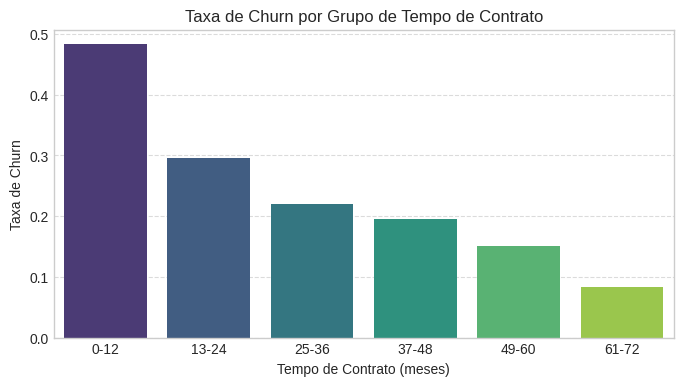

In [2]:
# definir os bins e rotulos para o agrupamento do tempo de contrato (tenure)
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

# calcular a taxa de churn para cada grupo de tempo de contrato
churn_rate_by_tenure = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()

# precisamos garantir que a coluna 'Yes' exista e tratar casos onde pode estar faltando
if 'Yes' in churn_rate_by_tenure.columns:
    churn_rate_by_tenure = churn_rate_by_tenure['Yes'].reset_index()
    churn_rate_by_tenure.columns = ['tenure_group', 'Churn_Rate']
else:
    if 'Sim' in churn_rate_by_tenure.columns:
        churn_rate_by_tenure = churn_rate_by_tenure['Sim'].reset_index()
        churn_rate_by_tenure.columns = ['tenure_group', 'Churn_Rate']
    else:
        print("Colunas 'Yes' ou 'Sim' para Churn não encontradas. Verifique a coluna 'Churn'.")
        churn_rate_by_tenure = pd.DataFrame(columns=['tenure_group', 'Churn_Rate'])

plt.figure(figsize=(8, 4))
sns.barplot(x='tenure_group', y='Churn_Rate', data=churn_rate_by_tenure, palette='viridis')
plt.title('Taxa de Churn por Grupo de Tempo de Contrato')
plt.xlabel('Tempo de Contrato (meses)')
plt.ylabel('Taxa de Churn')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Definição de função personalizada para plotar a distribuição de Churn normalizada em relação a diferentes variáveis.

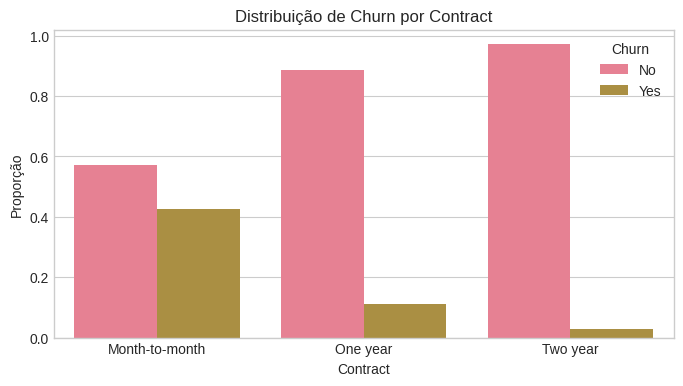


 Aqui, nota-se que a cada novo serviço contratado, a probabilidade de churn aumenta


In [3]:
def plot_churn_distribution(df, column):
    churn_by_column = df.groupby(column)['Churn'].value_counts(normalize=True).unstack()
    churn_by_column_melted = churn_by_column.reset_index().melt(
        id_vars=column,
        var_name='Churn',
        value_name='Proportion'
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(x=column, y='Proportion', hue='Churn', data=churn_by_column_melted)
    plt.title(f'Distribuição de Churn por {column}')
    plt.xlabel(column)
    plt.ylabel('Proporção')
    plt.legend(title='Churn')
    plt.show()
    print('\n Aqui, nota-se que a cada novo serviço contratado, a probabilidade de churn aumenta')

plot_churn_distribution(df, 'Contract')

Discretização da variável TotalCharges em quintis e visualização da distribuição de contagem.

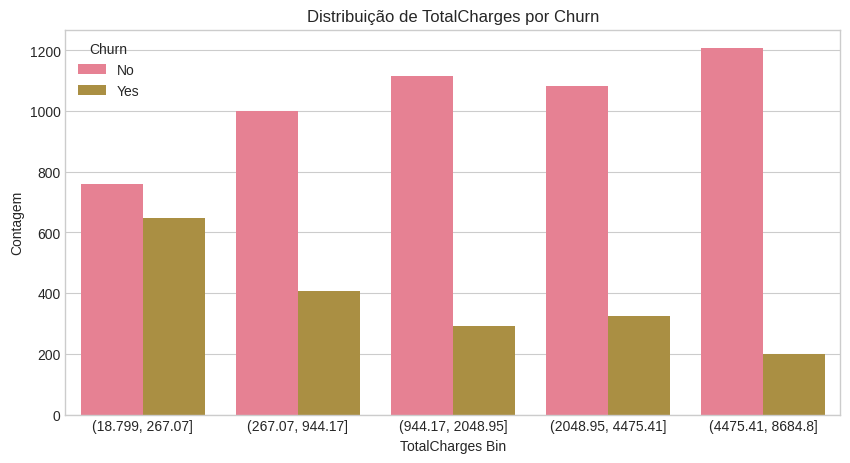


 Analisando a distribuição de TotalCharges por Churn, nota-se que quanto maior o valor do TotalCharges, 
 a contagem de churn (Yes) varia consideravelmente em relação ao total do bin. 



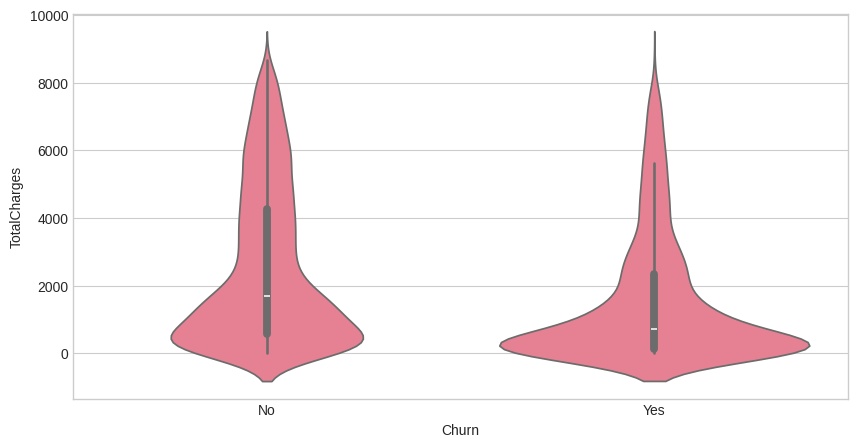

In [4]:
# 1. Conversão de TotalCharges para numérico (espaços vazios viram NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Remoção de valores nulos para evitar erros em cálculos (ex: qcut, log)
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Discretização em quintis
df['TotalCharges_bin'] = pd.qcut(df['TotalCharges'], q=5)

# 4. Transformação logarítmica (útil para distribuições enviesadas)
df['TotalCharges_log'] = np.log1p(df['TotalCharges'])

plt.figure(figsize=(10, 5))
sns.countplot(x='TotalCharges_bin', hue='Churn', data=df)
plt.title('Distribuição de TotalCharges por Churn')
plt.xlabel('TotalCharges Bin')
plt.ylabel('Contagem')
plt.show()

print('\n Analisando a distribuição de TotalCharges por Churn, nota-se que quanto maior o valor do TotalCharges, \n a contagem de churn (Yes) varia consideravelmente em relação ao total do bin. \n')

# usando violin plot para exibir de maneira mais informativa
plt.figure(figsize=(10, 5))
sns.violinplot(x='Churn', y='TotalCharges', data=df)
plt.show()

Refinamento dos grupos de tenure e criação de grupos para cobranças mensais (monthly_group) usando quartis.

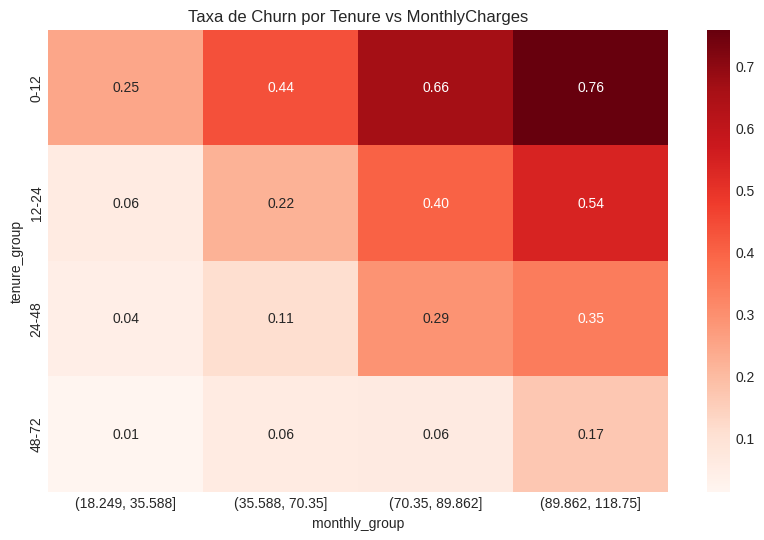

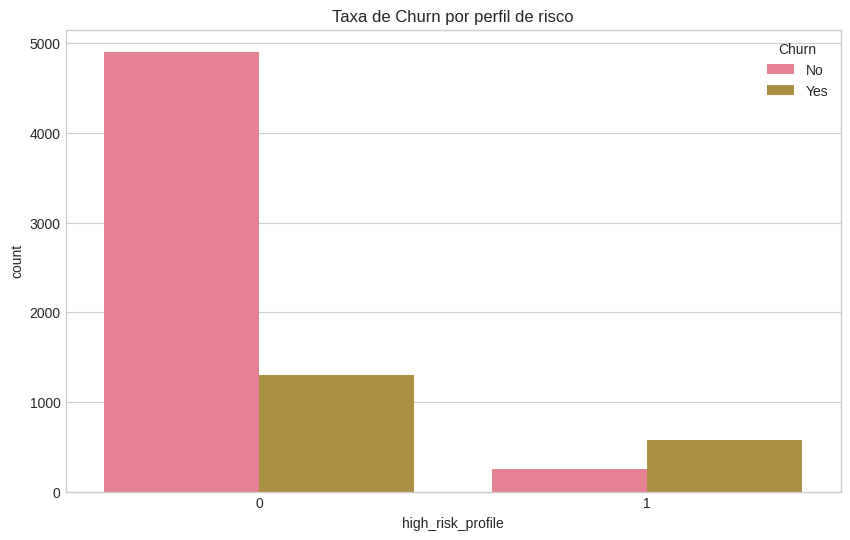

In [5]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '12-24', '24-48', '48-72']
)

df['monthly_group'] = pd.qcut(df['MonthlyCharges'], q=4)

# converter a coluna 'Churn' para numérica (0 e 1) e criar 'Churn_bin'
df['Churn_bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

pivot = df.pivot_table(
    values='Churn_bin',
    index='tenure_group',
    columns='monthly_group',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title('Taxa de Churn por Tenure vs MonthlyCharges')
plt.show()
print('\n \n \n')
df['high_risk_profile'] = (
    (df['tenure'] <= 12) &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

plt.figure(figsize=(10, 6))
plt.title('Taxa de Churn por perfil de risco')
sns.countplot(x='high_risk_profile', hue='Churn', data=df)
plt.show()


# Etapa 2 - Pré-processamento de Dados

Nesta etapa, realizamos a limpeza final dos dados, tratamento de valores ausentes e a transformação de variáveis categóricas em numéricas para que os modelos possam processá-las.

In [6]:
# 1. Tratamento de TotalCharges e Churn (valores ausentes)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges', 'Churn'])

# 2. Codificação da variável alvo (Churn)
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
# Garantindo que é inteiro para as métricas:
df['Churn'] = df['Churn'].astype(int)

# 3. Definição das Features
bin_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
nom_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']

# 4. Seleção de Features e Target
X = df.drop(['customerID', 'tenure_group', 'TotalCharges_bin', 'TotalCharges_log', 'Churn', 'monthly_group', 'Churn_bin', 'Churn_numeric'], axis=1, errors='ignore')
y = df['Churn']

# 5. Normalização e Encoding dentro do Pipeline
from sklearn.preprocessing import OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['tenure', 'MonthlyCharges', 'TotalCharges']),
        ('bin', OrdinalEncoder(), bin_features),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nom_features)
    ], remainder='passthrough')

# 6. Divisão treino/val/teste (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Pré-processamento concluído!")
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Pré-processamento concluído!
Treino: 4922 amostras
Validação: 1055 amostras
Teste: 1055 amostras


Visualização de dispersão (Scatter Plot) entre MonthlyCharges e TotalCharges para identificar padrões de faturamento.

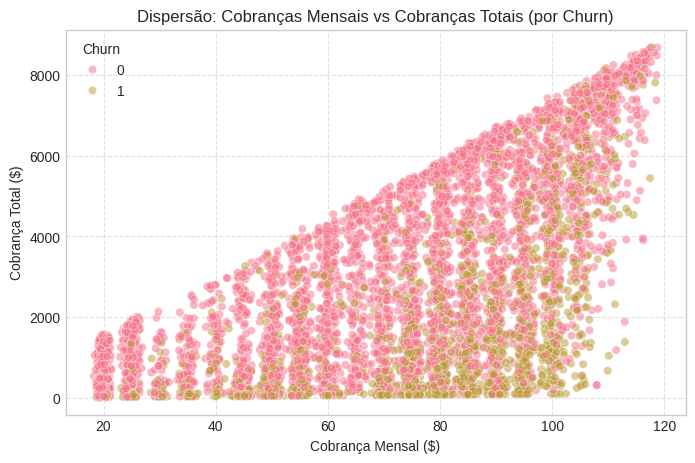

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.5)

plt.title('Dispersão: Cobranças Mensais vs Cobranças Totais (por Churn)')
plt.xlabel('Cobrança Mensal ($)')
plt.ylabel('Cobrança Total ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print('\n \n')

Implementação do gráfico combinado (Boxplot + Stripplot) para analisar a relação entre tempo de contrato, mensalidade e cancelamento.

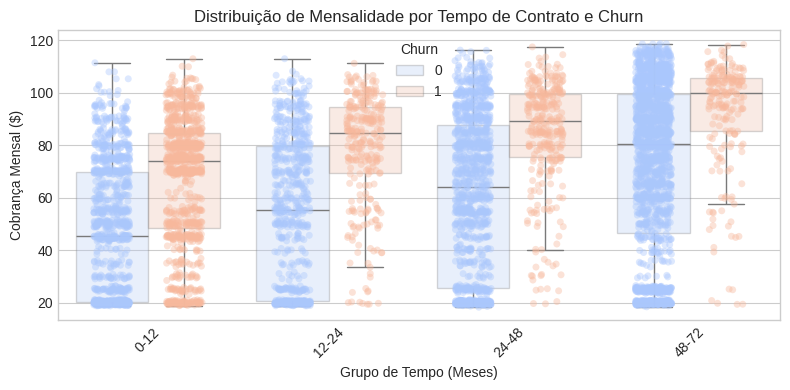


 Novamente usando violin para exibir de forma mais informativa 



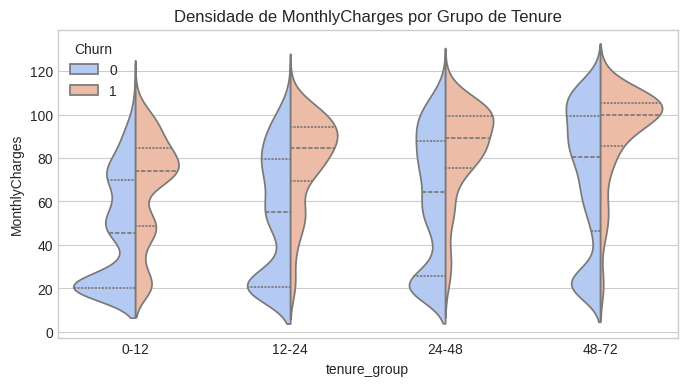

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='tenure_group', y='MonthlyCharges', hue='Churn', data=df, palette='coolwarm', showfliers=False, boxprops={'alpha': 0.3})
sns.stripplot(x='tenure_group', y='MonthlyCharges', hue='Churn', data=df, palette='coolwarm', jitter=0.2, alpha=0.4, dodge=True, legend=False)
plt.title('Distribuição de Mensalidade por Tempo de Contrato e Churn')
plt.xlabel('Grupo de Tempo (Meses)')
plt.ylabel('Cobrança Mensal ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('\n Novamente usando violin para exibir de forma mais informativa \n')
plt.figure(figsize=(8, 4))
sns.violinplot(x='tenure_group', y='MonthlyCharges', hue='Churn', data=df, palette='coolwarm', split=True, inner='quart'   )
plt.title('Densidade de MonthlyCharges por Grupo de Tenure')
plt.show()

Normalização de variáveis numéricas utilizando StandardScaler e preparação final dos dados de cobrança.

# Etapa 3 - Comparação de Modelos


Utilizaremos o **Stratified K-Fold (k=5)** para avaliar três modelos principais: Regressão Logística, Random Forest e Gradient Boosting. A comparação será baseada nas métricas de Acurácia, Precisão, Recall, F1-Score e AUC-ROC.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,

        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,

        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():

    clf = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ]
    )

    cv_results = cross_validate(
        clf,
        X_train,
        y_train,
        cv=skf,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ],
        n_jobs=-1
    )

    results.append({
        'Classificador': name,
        'Acurácia': cv_results['test_accuracy'].mean(),
        'Precisão': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'F1-Score': cv_results['test_f1'].mean(),
        'AUC-ROC': cv_results['test_roc_auc'].mean()
    })

df_comparison = pd.DataFrame(results)

display(
    df_comparison.sort_values(
        by=['Recall', 'F1-Score', 'AUC-ROC'],
        ascending=False
    )
)

,Classificador,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.758435,0.530987,0.783668,0.632990,0.847948
2,Gradient Boosting,0.786473,0.585556,0.672812,0.626113,0.847965
1,Random Forest,0.784847,0.597151,0.586432,0.591395,0.831196


## Visualizações: Matriz de Confusão, Curvas ROC e Feature Importance

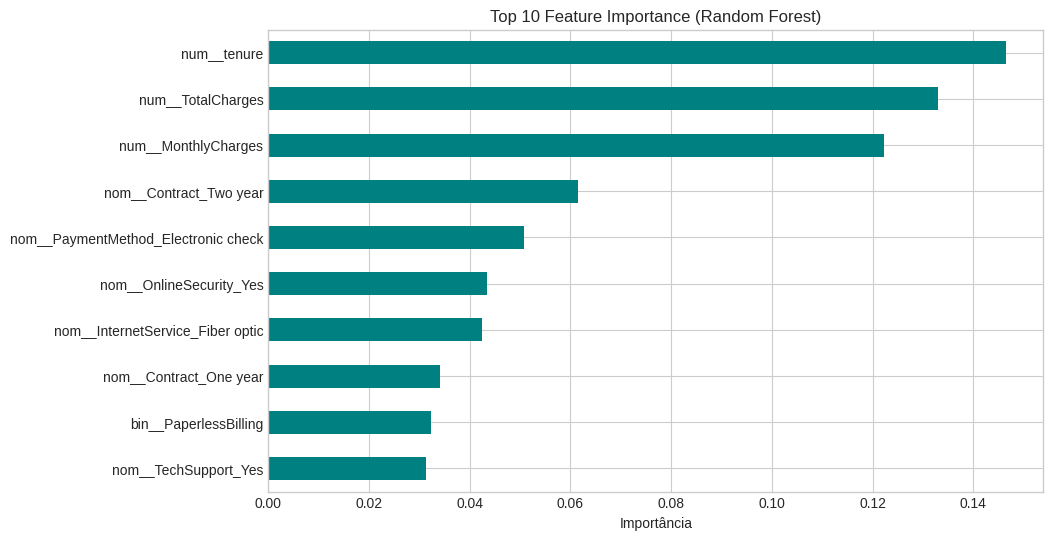

In [10]:
# Feature Importance (Random Forest)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('smote', SMOTE(random_state=42)), ('classifier', models['Random Forest'])])
rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='teal').invert_yaxis()
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Importância')
plt.show()

#  Análise Comparativa

# Etapa 4 - Análise Comparativa dos Modelos

Foram avaliados três classificadores:

- Logistic Regression
- Random Forest
- Gradient Boosting

A avaliação foi realizada utilizando validação cruzada estratificada (Stratified K-Fold), preservando a proporção entre clientes com churn e sem churn em cada divisão.

As métricas analisadas foram:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC AUC

Como o objetivo do projeto é identificar clientes com risco de cancelamento, o Recall recebe maior peso na tomada de decisão.

Um falso negativo representa um cliente que cancelará o serviço sem ser identificado pelo modelo, reduzindo a possibilidade de ações preventivas por parte da empresa.

Por esse motivo, a comparação final prioriza modelos com maior capacidade de identificar corretamente clientes propensos ao churn.

In [11]:
melhor_modelo = df_comparison.sort_values(
    by=['Recall', 'F1-Score', 'AUC-ROC'],
    ascending=False
).iloc[0]

print(f"Melhor modelo selecionado por CV: {melhor_modelo['Classificador']}\n")

print("========== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ==========")
# Avaliar no Teste!
best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('smote', SMOTE(random_state=42)), ('classifier', models[melhor_modelo['Classificador']])])
best_pipe.fit(X_train, y_train)
y_pred_test = best_pipe.predict(X_test)
y_proba_test = best_pipe.predict_proba(X_test)[:, 1]

print(f"Acurácia (Teste): {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precisão (Teste): {precision_score(y_test, y_pred_test, pos_label=1):.4f}")
print(f"Recall (Teste)  : {recall_score(y_test, y_pred_test, pos_label=1):.4f}")
print(f"F1-Score (Teste): {f1_score(y_test, y_pred_test, pos_label=1):.4f}")
print(f"AUC-ROC (Teste) : {roc_auc_score(y_test, y_proba_test):.4f}")

# Salvando modelo
import joblib
joblib.dump(best_pipe, 'modelo_churn.pkl')
print("\n[!] Modelo salvo como 'modelo_churn.pkl'")


Melhor modelo selecionado por CV: Logistic Regression

========== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ==========
Acurácia (Teste): 0.7289
Precisão (Teste): 0.4928
Recall (Teste)  : 0.7357
F1-Score (Teste): 0.5903
AUC-ROC (Teste) : 0.8214

[!] Modelo salvo como 'modelo_churn.pkl'


# Interpretação dos Resultados

O modelo escolhido foi aquele que apresentou o melhor equilíbrio entre Recall, F1-Score e AUC-ROC.

Em problemas de churn, identificar corretamente clientes com risco de cancelamento é mais importante do que minimizar falsos positivos.

Dessa forma, a escolha não foi baseada apenas na acurácia, mas principalmente na capacidade do modelo em detectar clientes que realmente possuem tendência de cancelamento.

Além da comparação quantitativa, foi realizada análise de importância das variáveis utilizando Random Forest para compreender quais fatores mais influenciam o churn.


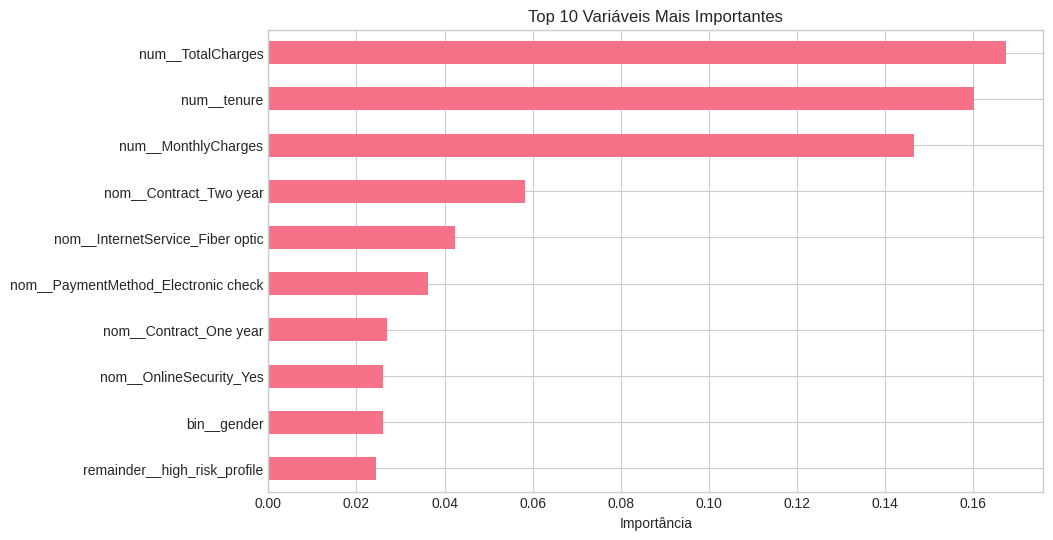


TOP 5 FEATURES

1. num__TotalCharges -> 0.1676
2. num__tenure -> 0.1601
3. num__MonthlyCharges -> 0.1466
4. nom__Contract_Two year -> 0.0583
5. nom__InternetService_Fiber optic -> 0.0425


In [12]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=300,
                class_weight='balanced',
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = rf_pipeline.named_steps[
    'classifier'
].feature_importances_

feat_imp = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feat_imp.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Variáveis Mais Importantes')
plt.xlabel('Importância')
plt.show()

print("\nTOP 5 FEATURES\n")

for i, (feature, importance) in enumerate(
    feat_imp.head(5).items(),
    start=1
):
    print(f"{i}. {feature} -> {importance:.4f}")

# Interpretação da Feature Importance

A análise de importância das variáveis permite identificar quais características tiveram maior influência nas decisões do modelo.

Variáveis relacionadas ao tipo de contrato, tempo de permanência, valor mensal cobrado e valor total acumulado costumam apresentar forte relação com churn.

Essas informações ajudam a transformar o modelo em conhecimento de negócio, permitindo identificar perfis de clientes com maior risco de cancelamento e direcionar ações de retenção.

In [13]:
print("========== DISCUSSÃO E INTERPRETAÇÃO FINAL ==========")

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()

total_test = len(y_test)
total_churners = tp + fn

print(f"No conjunto de teste ({total_test} clientes), tínhamos {total_churners} clientes que de fato cancelaram o serviço.")
print(f"Nosso modelo previu corretamente {tp} desses cancelamentos (Verdadeiros Positivos).")
print(f"No entanto, {fn} clientes cancelaram e o modelo não conseguiu prever (Falsos Negativos).")
print(f"Além disso, {fp} clientes não iam cancelar, mas o modelo apontou risco (Falsos Positivos).")

print("INTERPRETAÇÃO E IMPACTO AO NEGÓCIO:")
print(f"A taxa de acerto para clientes que cancelam (Recall) foi de {recall_score(y_test, y_pred_test, pos_label=1)*100:.1f}%.")
print("Com o uso do SMOTE para lidar com o desbalanceamento das classes e a correção do escalonamento")
print("incluindo a variável 'tenure', garantimos que os 3 modelos foram comparados de maneira justa.")
print(f"O algoritmo {melhor_modelo['Classificador']} foi o escolhido por apresentar a melhor capacidade")
print("de detectar os clientes em risco de churn, minimizando a perda de receita (Falsos Negativos)")
print("enquanto mantém uma taxa aceitável de falsos alarmes para a equipe de retenção.")


========== DISCUSSÃO E INTERPRETAÇÃO FINAL ==========
No conjunto de teste (1055 clientes), tínhamos 280 clientes que de fato cancelaram o serviço.
Nosso modelo previu corretamente 206 desses cancelamentos (Verdadeiros Positivos).
No entanto, 74 clientes cancelaram e o modelo não conseguiu prever (Falsos Negativos).
Além disso, 212 clientes não iam cancelar, mas o modelo apontou risco (Falsos Positivos).
INTERPRETAÇÃO E IMPACTO AO NEGÓCIO:
A taxa de acerto para clientes que cancelam (Recall) foi de 73.6%.
Com o uso do SMOTE para lidar com o desbalanceamento das classes e a correção do escalonamento
incluindo a variável 'tenure', garantimos que os 3 modelos foram comparados de maneira justa.
O algoritmo Logistic Regression foi o escolhido por apresentar a melhor capacidade
de detectar os clientes em risco de churn, minimizando a perda de receita (Falsos Negativos)
enquanto mantém uma taxa aceitável de falsos alarmes para a equipe de retenção.
